In [81]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [82]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start = start, end = end)

/tmp/ipython-input-721774731.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start = start, end = end)
[*********************100%***********************]  1 of 1 completed


In [83]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [84]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-12-02,91350.203125,92316.632812,86202.195312,86322.539062,78546798211
2025-12-03,93527.804688,94060.773438,91056.390625,91345.093750,77650204986
2025-12-04,92141.625000,94038.242188,90976.101562,93454.257812,64538402681
2025-12-05,89387.757812,92702.640625,88152.140625,92133.648438,63256398633
2025-12-06,89625.765625,89793.898438,89124.484375,89360.835938,58932563968


In [85]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,BTC-USD,4099.0,2.647187e+04,3.137612e+04,1.781030e+02,2.632300e+03,1.062354e+04,4.169976e+04,1.247525e+05
High,BTC-USD,4099.0,2.698532e+04,3.190185e+04,2.117310e+02,2.758235e+03,1.089876e+04,4.251759e+04,1.261981e+05
Low,BTC-USD,4099.0,2.588459e+04,3.078605e+04,1.715100e+02,2.543790e+03,1.031309e+04,4.067016e+04,1.231960e+05
Open,BTC-USD,4099.0,2.645114e+04,3.136396e+04,1.768970e+02,2.608345e+03,1.061982e+04,4.164804e+04,1.247521e+05
Volume,BTC-USD,4099.0,2.150476e+10,2.285752e+10,5.914570e+06,1.207830e+09,1.697592e+10,3.291268e+10,3.509679e+11


In [86]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4099 entries, 2014-09-17 to 2025-12-06
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4099 non-null   float64
 1   (High, BTC-USD)    4099 non-null   float64
 2   (Low, BTC-USD)     4099 non-null   float64
 3   (Open, BTC-USD)    4099 non-null   float64
 4   (Volume, BTC-USD)  4099 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 192.1 KB


In [87]:
stock_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [88]:
#Close price data
closing_price = stock_data[['Close']]

In [89]:
closing_price

Price,Close
Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2025-12-02,91350.203125
2025-12-03,93527.804688


<function matplotlib.pyplot.show(close=None, block=None)>

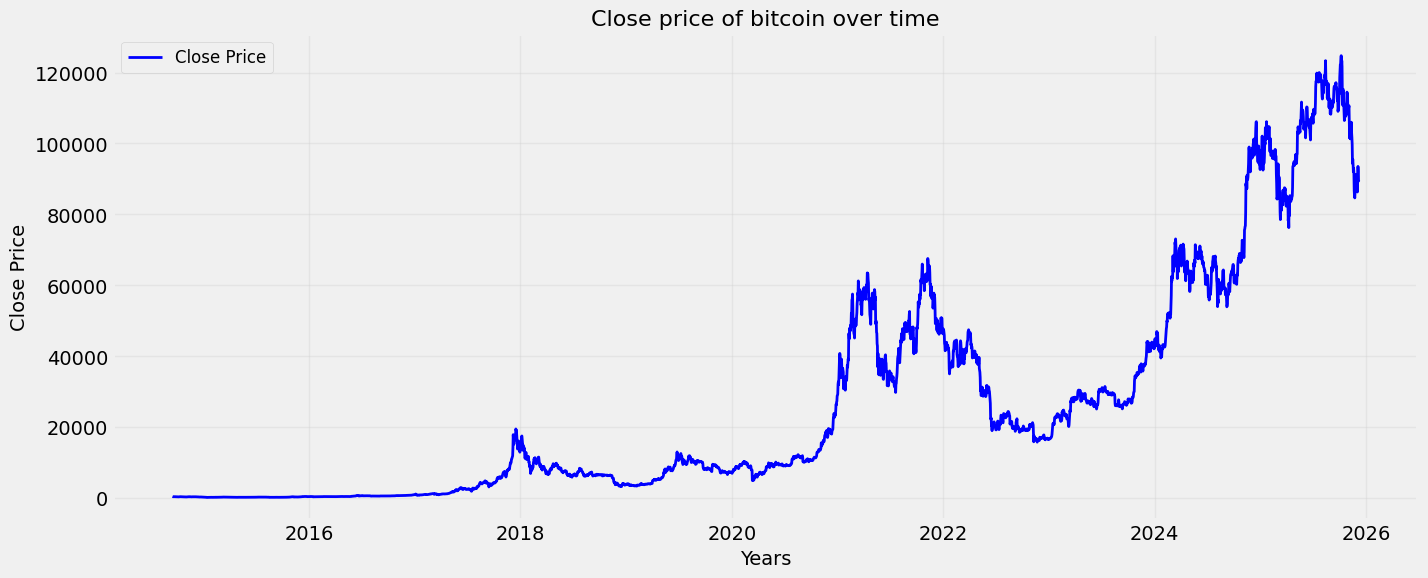

In [90]:
#Plot closing price with enhancement
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth = 2)
plt.title("Close price of bitcoin over time", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show

In [91]:
#Moving Average
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90 ,100]
# moving average for 5-day -> null null null null 30.0 40.0
print(sum(temp_data[1:6])/5)

40.0


In [92]:
df1 = pd.DataFrame(temp_data)

In [93]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [94]:
for i in range (2014, 2025):
  print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366


In [95]:
closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

/tmp/ipython-input-194502310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
/tmp/ipython-input-194502310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


<function matplotlib.pyplot.show(close=None, block=None)>

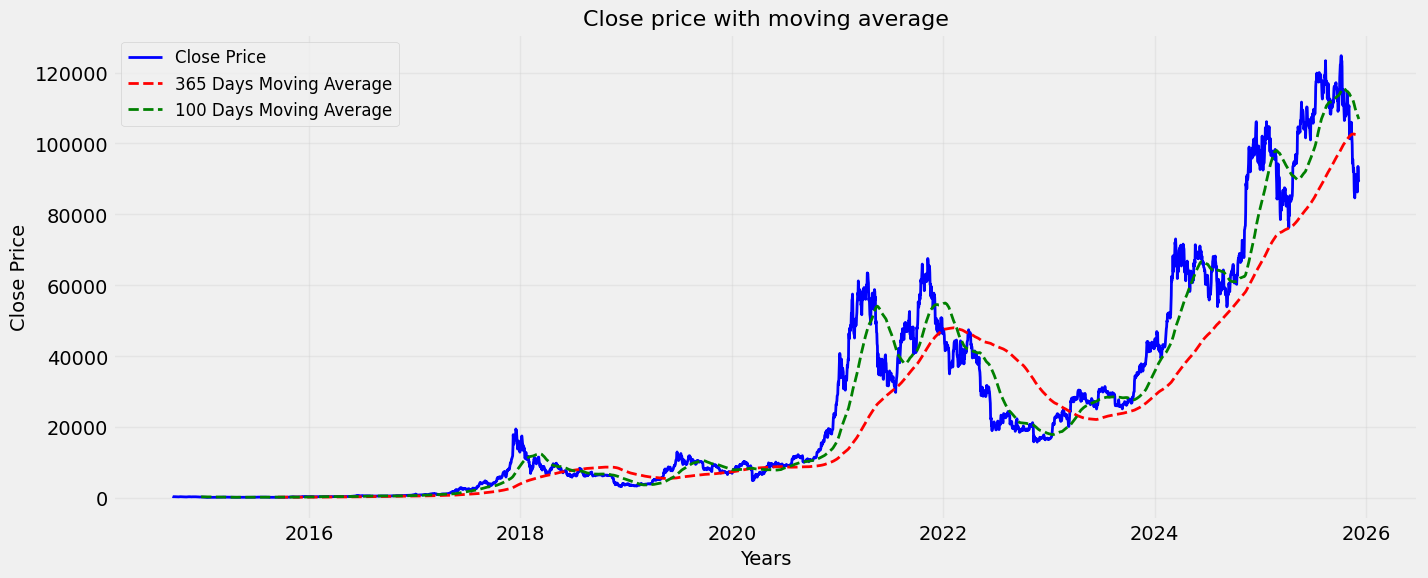

In [96]:
#Plot closing price with enhancement
plt.figure(figsize = (15,6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Days Moving Average', color = 'red', linestyle ="--", linewidth = 2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Days Moving Average', color = 'green', linestyle ="--", linewidth = 2)

plt.title("Close price with moving average", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show

In [97]:
# LSTM -> Long short term memory
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [98]:
len(scaled_data)

4099

In [99]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [100]:
# Prepare data for Lstm
x_data = []
y_data = []
base_days = 100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days: i])
    y_data.append(scaled_data[i])
x_data = np.array(x_data)
y_data = np.array(y_data)

In [101]:
# Split into train and test sets
train_size = int(len(x_data) * 0.9)
x_train = x_data[:train_size]
y_train = y_data[:train_size]

x_test = x_data[train_size:]
y_test = y_data[train_size:]

In [102]:
model = Sequential([
    LSTM(128, return_sequences = True, input_shape = (x_train.shape[1], 1)),
    LSTM(64, return_sequences = False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer = "adam", loss = "mean_squared_error")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 68s 90ms/step - loss: 0.0013
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 64s 89ms/step - loss: 2.1044e-04
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 65s 91ms/step - loss: 1.3890e-04
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - loss: 1.3323e-04
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 70s 98ms/step - loss: 1.5119e-04
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - loss: 1.0400e-04
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - loss: 1.0366e-04
Epoch 8/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step - loss: 1.4626e-04
Epoch 9/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 64s 89ms/step - loss: 1.1234e-04
Epoch 10/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 64s 89ms/step - loss: 8.9965e-05


In [104]:
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step


In [105]:
test_len = len(inv_predictions)

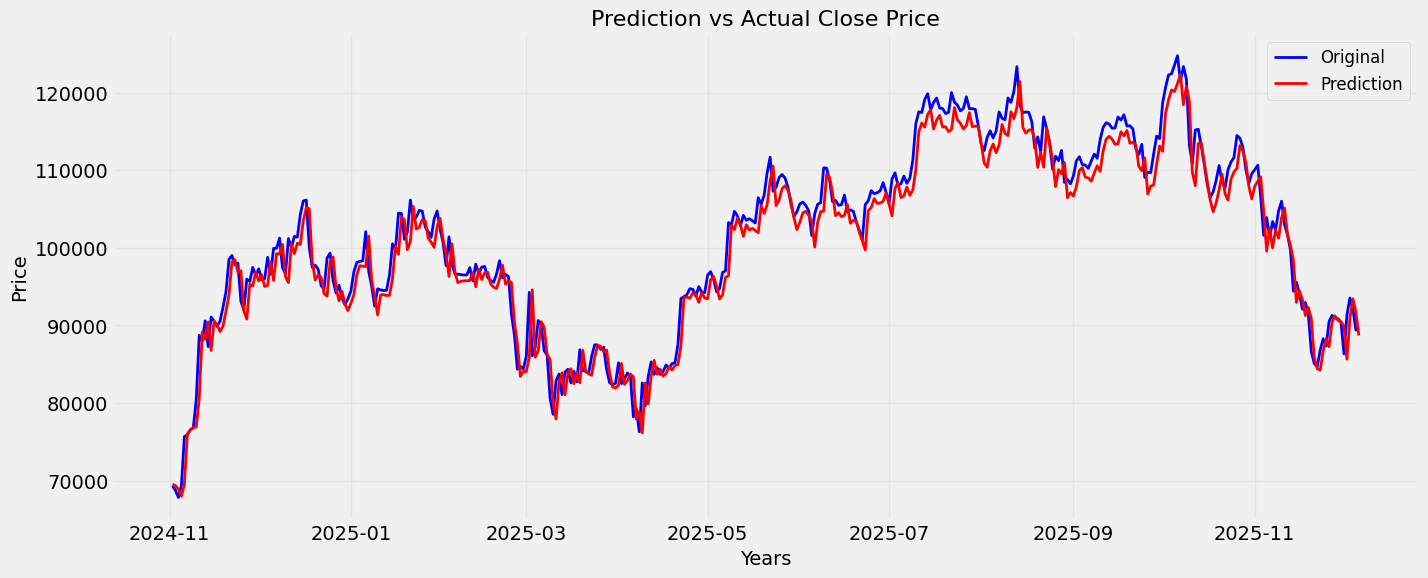

In [109]:
test_len = len(inv_predictions)

plot_index = closing_price.inde x[train_size + base_days : train_size + base_days + test_len]

plotting_data = pd.DataFrame({
    'Original': inv_y_test.flatten(),
    'Prediction': inv_predictions.flatten(),
}, index = plot_index)

plt.figure(figsize=(15,6))
plt.plot(plotting_data.index, plotting_data['Original'], label='Original', color = 'blue', linewidth=2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label='Prediction', color = 'red', linewidth=2)
plt.title("Prediction vs Actual Close Price", fontsize=16)
plt.xlabel("Years", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [110]:
#Predict future days
last_100 = scaled_data[-100:].reshape(1, -1, 1)
future_predictions=[]
for _ in range(10):
  next_days = model.predict(last_100)
  future_predictions.append(scaler.inverse_transform(next_days))
  last_100 = np.append(last_100[:, 1:, :], next_days.reshape(1, 1, -1), axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


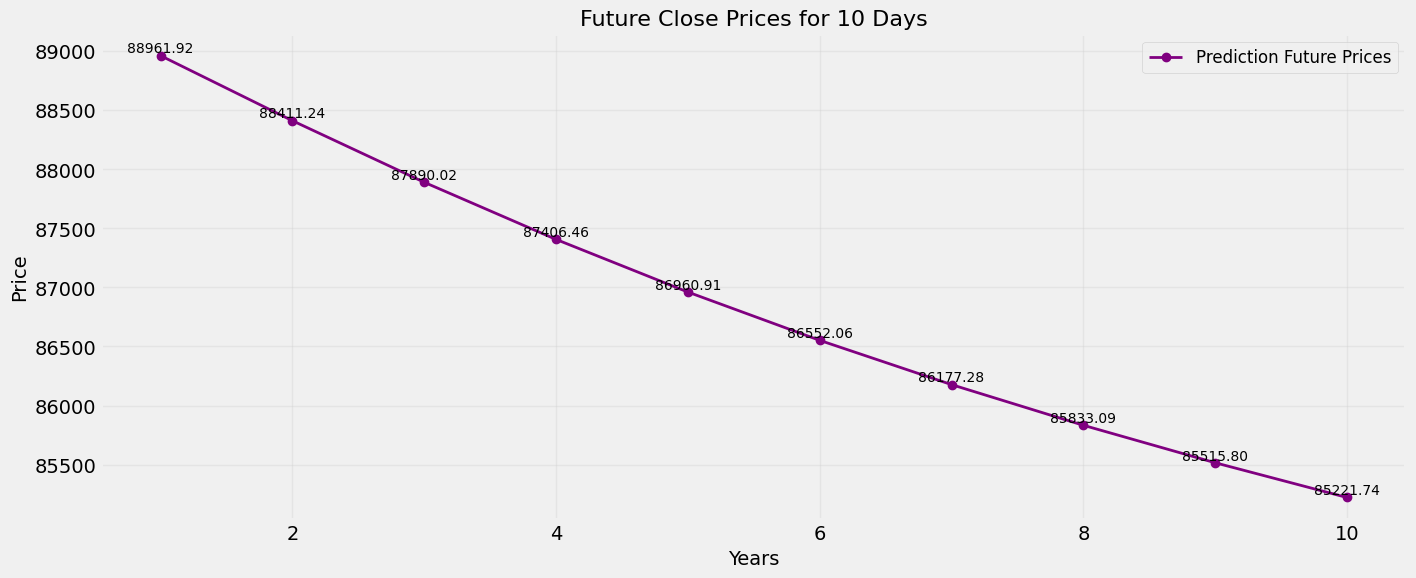

In [111]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize=(15,6))
plt.plot(range(1, 11), future_predictions, marker = "o", label='Prediction Future Prices', color = 'purple', linewidth=2)

for i, val in enumerate(future_predictions):
  plt.text(i+1, val, f'{val:.2f}', fontsize = 10, ha = 'center', va = 'bottom', color = 'black')

plt.title("Future Close Prices for 10 Days", fontsize=16)
plt.xlabel("Years", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In [112]:
model.save("model.keras")